# Parte I

El dataset `nacimientos.csv` contiene la siguiente información registrada en un efector de salud sobre un total de 345 madres que dieron a luz en el último año: peso del recién nacido (kg), semanas de gestación, número de partos previos atravesados y edad de la madre al momento del nacimiento. Por otro lado, se registró el peso (kg) y la altura (m) de las mujeres luego del parto y se las indagó acerca del número de cigarrillos que suelen consumir a diario, información que se encuentra en el dataset `datos_madres.xlsx`.

In [97]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

### Ejercicio 1

Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y adecuación de los mismos que considere necesaria para su posterior análisis.

In [98]:
# Cargamos los dataframes

nacimientos = pd.read_csv('../../datasets/nacimientos.csv', delimiter=';', header=3)
nacimientos.head()

,id_madre,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos
0,1,3057.4,38.8,21,1
1,2,2716.6,38.1,26,0
2,3,3230.8,39.1,18,1
3,4,3473.3,41.8,28,2
4,5,2951.5,38.0,29,3


In [99]:
nacimientos.info()

# Podemos observar que no hay valores faltantes o nulos.

<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_madre       345 non-null    int64  
 1   peso_kg_bebe   345 non-null    float64
 2   semanas_gest   345 non-null    float64
 3   edad_anios     345 non-null    int64  
 4   hijos_previos  345 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 13.6 KB


In [100]:
# vamos a cambiar el nombre de la columna 'id_madre' por 'id'

nacimientos = nacimientos.rename(columns={'id_madre': 'id'})
nacimientos.head()

,id,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos
0,1,3057.4,38.8,21,1
1,2,2716.6,38.1,26,0
2,3,3230.8,39.1,18,1
3,4,3473.3,41.8,28,2
4,5,2951.5,38.0,29,3


In [101]:
madres = pd.read_excel('../../datasets/datos_madres.xlsx')
madres.head()

,ID,ALTURA_M_MUJER,PESO_KG_MUJER,NUM_CIGARRILLOS_DIA
0,1,"1,6",45.4,0
1,2,"1,6",61.2,9
2,3,"1,6",52.2,2
3,4,"1,8",86.2,0
4,5,"1,7",56.7,4


In [102]:
madres.info()

<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   345 non-null    int64  
 1   ALTURA_M_MUJER       345 non-null    str    
 2   PESO_KG_MUJER        345 non-null    float64
 3   NUM_CIGARRILLOS_DIA  345 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 10.9 KB


In [103]:
# La única variable no numérica es la altura de la madre, que vamos a convertir a numérica. 
# También vamos a cambiar el nombre de las columnas para cambiar las mayúsculas por minúsculas.

madres = madres.rename(columns={'ID': 'id', 'ALTURA_M_MUJER': 'altura_m_mujer', 
                                'PESO_KG_MUJER' : 'peso_kg_mujer', 'NUM_CIGARRILLOS_DIA' : 'num_cigarrillos_dia'})

madres['altura_m_mujer'] = madres['altura_m_mujer'].str.replace(',', '.')
madres['altura_m_mujer'] = pd.to_numeric(madres['altura_m_mujer'], errors='coerce')


In [104]:
# Finalmente, vamos a unir los datos en un solo dataframe utilizando la columna 'id' como clave.

datos = pd.merge(nacimientos, madres, on='id')
datos.head()

,id,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos,altura_m_mujer,peso_kg_mujer,num_cigarrillos_dia
0,1,3057.4,38.8,21,1,1.6,45.4,0
1,2,2716.6,38.1,26,0,1.6,61.2,9
2,3,3230.8,39.1,18,1,1.6,52.2,2
3,4,3473.3,41.8,28,2,1.8,86.2,0
4,5,2951.5,38.0,29,3,1.7,56.7,4


In [105]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   345 non-null    int64  
 1   peso_kg_bebe         345 non-null    float64
 2   semanas_gest         345 non-null    float64
 3   edad_anios           345 non-null    int64  
 4   hijos_previos        345 non-null    int64  
 5   altura_m_mujer       345 non-null    float64
 6   peso_kg_mujer        345 non-null    float64
 7   num_cigarrillos_dia  345 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 21.7 KB


## Ejercicio 2

Considerando que el Índice de Masa Corporal (IMC) se define como el peso de una persona en kilogramos dividido por el cuadrado de la estatura en metros, represente gráficamente la distribución de dicha variable para las mujeres del dataset. En base al gráfico realizado, ¿cómo caracterizaría su distribución en relación a la simetría?

In [106]:
# Agregamos la variable imc_madre que se calcula como el peso en kg dividido por la altura en metros al cuadrado.

datos['imc_madre'] = round(datos['peso_kg_mujer'] / (datos['altura_m_mujer'] ** 2), 2)
datos.head()

,id,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos,altura_m_mujer,peso_kg_mujer,num_cigarrillos_dia,imc_madre
0,1,3057.4,38.8,21,1,1.6,45.4,0,17.73
1,2,2716.6,38.1,26,0,1.6,61.2,9,23.91
2,3,3230.8,39.1,18,1,1.6,52.2,2,20.39
3,4,3473.3,41.8,28,2,1.8,86.2,0,26.60
4,5,2951.5,38.0,29,3,1.7,56.7,4,19.62


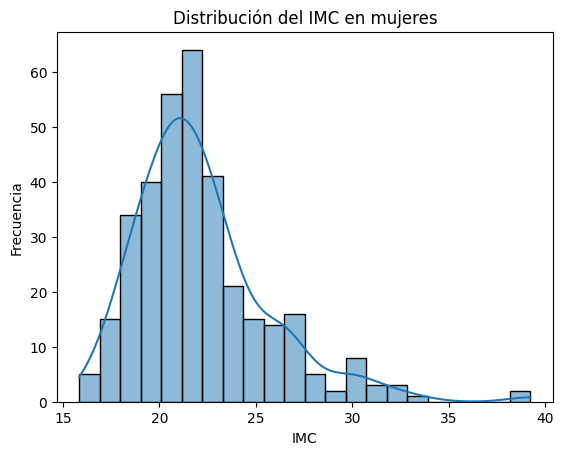

In [107]:
sns.histplot(
    datos["imc_madre"],
    kde=True
)

plt.xlabel("IMC")
plt.ylabel("Frecuencia")
plt.title("Distribución del IMC en mujeres")

plt.show()

La distribución presenta una asimetría positiva (sesgo a la derecha). La mayoría de las observaciones se concentran en valores medios bajos de IMC, mientras que existe una menor cantidad de mujeres con valores elevados que generan una cola hacia la derecha.

## Ejercicio 3

Genere una variable categórica binaria realizando la dicotomización de la variable vinculada con el número de cigarrillos consumidos a diario, diferenciando aquellas mujeres que no fuman habitualmente (no consumen cigarrillos) de aquellas que sí lo hacen (consumen 1 o más cigarrillos diariamente). ¿Qué porcentaje de las mujeres del dataset son fumadoras?

In [108]:
# Generamos la variable dicotomica 

datos['madre_fumadora'] = datos['num_cigarrillos_dia'].apply(lambda x: 1 if x >= 1 else 0)
datos.head()

,id,peso_kg_bebe,semanas_gest,edad_anios,hijos_previos,altura_m_mujer,peso_kg_mujer,num_cigarrillos_dia,imc_madre,madre_fumadora
0,1,3057.4,38.8,21,1,1.6,45.4,0,17.73,0
1,2,2716.6,38.1,26,0,1.6,61.2,9,23.91,1
2,3,3230.8,39.1,18,1,1.6,52.2,2,20.39,1
3,4,3473.3,41.8,28,2,1.8,86.2,0,26.60,0
4,5,2951.5,38.0,29,3,1.7,56.7,4,19.62,1


In [109]:
# Calculamos el porcentaje de madres fumadoras

porcentaje_fumadoras = (datos['madre_fumadora'].sum() / len(datos)) * 100
print(f"El porcentaje de madres fumadoras es: {porcentaje_fumadoras:.2f}%")

El porcentaje de madres fumadoras es: 55.94%


## Ejercicio 4

Represente gráficamente la distribución del peso de los recién nacidos en función del carácter o no de fumadora de la madre (variable generada en el ítem anterior). Comente brevemente lo observado.

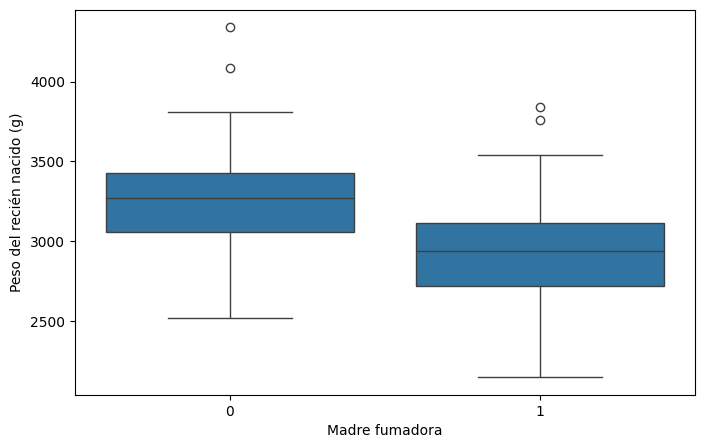

In [123]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=datos,
    x="madre_fumadora",
    y="peso_kg_bebe"
)

plt.xlabel("Madre fumadora")
plt.ylabel("Peso del recién nacido (g)")
plt.show()

El gráfico muestra diferencias en la distribución del peso de los recién nacidos según la condición de fumadora de la madre. En particular, los hijos de madres fumadoras presentan, en promedio, pesos menores que los hijos de madres no fumadoras. Además, puede observarse una menor mediana del peso y una mayor proporción de valores bajos en el grupo de madres fumadoras. Esto sugiere una posible asociación negativa entre el hábito de fumar durante el embarazo y el peso al nacer

## Ejercicio 5

Realice un gráfico que le permita caracterizar el grado de asociación lineal que existe entre las diferentes variables cuantitativas estudiadas. ¿Cuáles son los pares de variables que presentan una asociación lineal más intensa? Justifique.

In [124]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   345 non-null    int64  
 1   peso_kg_bebe         345 non-null    float64
 2   semanas_gest         345 non-null    float64
 3   edad_anios           345 non-null    int64  
 4   hijos_previos        345 non-null    int64  
 5   altura_m_mujer       345 non-null    float64
 6   peso_kg_mujer        345 non-null    float64
 7   num_cigarrillos_dia  345 non-null    int64  
 8   imc_madre            345 non-null    float64
 9   madre_fumadora       345 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 27.1 KB


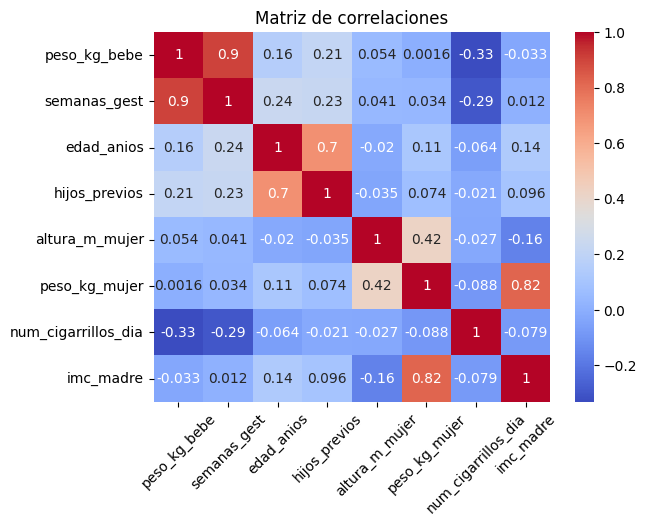

In [126]:
# Generamos el mapa de calor con las correlaciones entretodas las variables cuantitivas del dataframe.

sns.heatmap(
    datos[["peso_kg_bebe","semanas_gest","edad_anios","hijos_previos", "altura_m_mujer",
            "peso_kg_mujer", "num_cigarrillos_dia", "imc_madre"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlaciones")
plt.xticks(rotation=45)
plt.show()

Los pares de variables que presentan una asociación lineal (positiva) fuerte son 'altura_m_mujer' y 'imc_madre' (esperable), 'edad_anios' y  'hijos_previos', y 'semanas_gest' y 'peso_kg_bebe'. Siento este último par el más inteso con $0.9$.

# Parte II

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal múltiple que permita predecir el peso de los recién nacidos en función de las semanas de gestación, el número de partos previos atravesados por la madre, la edad de la madre, su índice de masa corporal (IMC) y el carácter o no de fumadora.

## Ejercicio a

Ajuste el modelo completo, incluyendo la totalidad de las variables predictoras de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar las diferencias en el peso promedio de los recién nacidos con un nivel de significación del 1%? Justifique.

Consideramos el modelo

$$Y = \beta_0 = \beta_1 X_{semGestacion} + \beta_2 X_{partosPrev} + \beta_3 X_{edad} + \beta_4 X_{imc} 
+ \beta_5 X_{fumadora}$$

donde 

- $Y$ es la variable asociad al peso de los recién nacios;
- $X_{semGestacion}$ es la variable asociada a la semanas de gestación;
- $X_{partosPrev}$ es la variable asociada a la cantidad de partos previos de la madre;
- $X_{edad}$ es la variable asociada a la edad de la madre;
- $X_{imc}$ es la variable asociada al IMC de la madre;
- $X_{fumadora}$ es 1 si la madre es fumadora y 0 en caso contrario.

In [130]:
modelo = smf.ols(
    formula = 'peso_kg_bebe ~ semanas_gest + edad_anios + hijos_previos + imc_madre + madre_fumadora',
    data = datos).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           peso_kg_bebe   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     356.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.50e-132
Time:                        17:29:47   Log-Likelihood:                -2177.1
No. Observations:                 345   AIC:                             4366.
Df Residuals:                     339   BIC:                             4389.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1531.1885    156.255     -9.

Con un nivel de significación del 1%, las variables 'semanas_gest', 'edad_anios' y 'madre_fumadora' contribuyen significativamente a explicar las diferencias en el peso promedio de los recién nacidos, dado que sus p-valores son menores que 0.01. Por el contrario, 'hijos_previos' y 'imc_madre' no resultan significativas al 1%, ya que sus p-valores superan dicho nivel de significación.

## Ejercicio b

Si a partir de su respuesta en el ítem anterior considera la posibilidad de ajustar un nuevomodelo que incluya menos variables predictoras que el modelo completo, realice el ajuste. De lo contrario, pase al ítem siguiente.



In [129]:
# En base a lo obtenido en el ítem anterior, ajustamos el modelo eliminando las variables
# hijos_previos e 'imc_madre' que no resultaron significativas.

modelo2 = smf.ols(
    formula='peso_kg_bebe ~ semanas_gest + edad_anios + madre_fumadora',
    data=datos
).fit()

print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:           peso_kg_bebe   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     570.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.61e-132
Time:                        17:29:12   Log-Likelihood:                -2183.7
No. Observations:                 345   AIC:                             4375.
Df Residuals:                     341   BIC:                             4391.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1732.4764    146.800    -11.

# Ejercicio c

Escriba la ecuación del modelo ajustado en forma desarrollada e interprete el valor del coeficiente
estimado por el modelo para la variable semanas de gestación.

Obtenemos el modelo

$$Y = -1732.4764 + 126.9094 X_{semGestacion} - 3.3426 \beta_3 X_{edad} - 89.6639 X_{fumadora}.$$

La variable semanas de gestación ($X_{semGestacion}$) tiene coeficiente 126.9094. Este es positivo y nos dice que por cada semana de gestación, el bebé tiene un aumento de $126.9094$ kg.

# Ejercicio d

Una médica quiere estimar el peso al nacer que tendrá un bebé que dará a luz una madre primeriza no fumadora de 25 años, que posee un índice de masa corporal de 19.5 kg/m2, luegode un total de 38 semanas de gestación. Utilice el último modelo ajustado para informarle un peso estimado.

In [133]:
# Usando el modelo anterior (ajustado), se tiene que

print('Estimación del peso del bebé:', round(modelo2.predict({'semanas_gest': 40, 
                                                                'edad_anios': 30, 
                                                                'madre_fumadora': 1}).values[0], 2), 'kg')

Estimación del peso del bebé: 3153.96 kg


# Ejercicio e

Represente gráficamente la distribución de los residuos del modelo y comente brevemente las
características que observa.

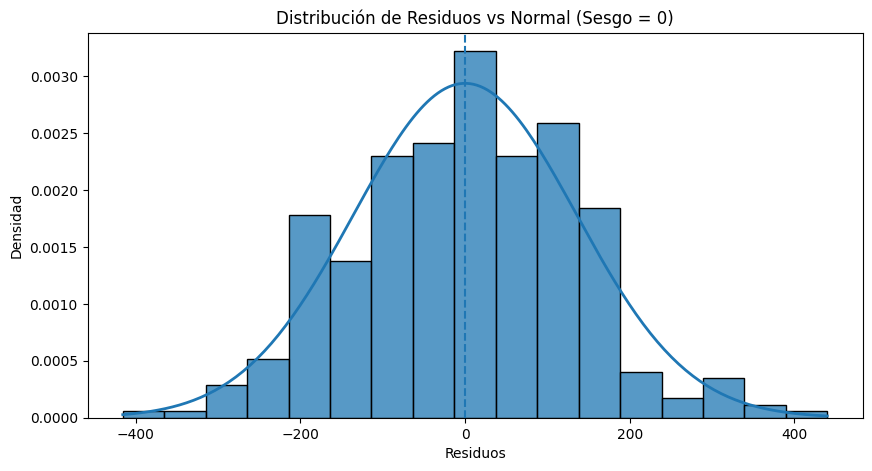

In [134]:
# Primero vamos a visualizar el sesgo en los residuos

residuos = modelo2.resid
media_res = np.mean(residuos)
std_res = np.std(residuos)

# Generación de valores para la curva normal teórica
x = np.linspace(min(residuos), max(residuos), 200)
normal_teorica = norm.pdf(x, loc=0, scale=std_res)  # Normal con media 0 (sin sesgo)

plt.figure(figsize=(10,5))

# Histograma + normal teórica
sns.histplot(residuos, kde=False, stat='density')
plt.plot(x, normal_teorica, linewidth=2)
plt.axvline(0, linestyle='--')  # Línea de media ideal
plt.title("Distribución de Residuos vs Normal (Sesgo = 0)")
plt.xlabel("Residuos")
plt.ylabel("Densidad")
plt.show()

La distribución de los residuos se encuentra centrada aproximadamente en cero y presenta una forma general similar a una distribución normal. Esto sugiere que el modelo no presenta un sesgo evidente en los residuos, lo cual es una buena señal para la validez del modelo. Sin embargo, es importante realizar pruebas estadísticas adicionales para confirmar esta observación.

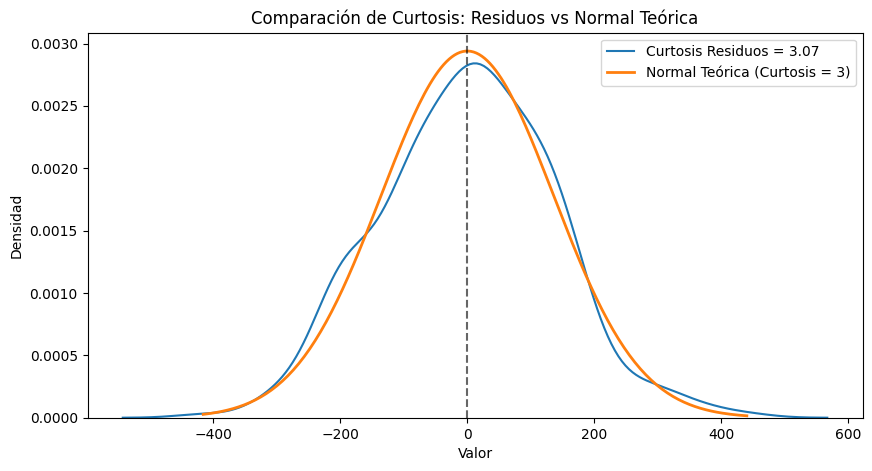

In [135]:
# Ahora continuamos con la curtosis

curt_residuos = kurtosis(residuos, fisher=False)  # fisher=False → curtosis normal = 3
media_res = np.mean(residuos)
std_res = np.std(residuos)

# Distribución normal teórica
x = np.linspace(min(residuos), max(residuos), 200)
normal_teorica = norm.pdf(x, loc=0, scale=std_res)

plt.figure(figsize=(10,5))

sns.kdeplot(residuos, label=f"Curtosis Residuos = {curt_residuos:.2f}")
plt.plot(x, normal_teorica, label="Normal Teórica (Curtosis = 3)", linewidth=2)

plt.axvline(0, linestyle="--", color="black", alpha=0.6)
plt.title("Comparación de Curtosis: Residuos vs Normal Teórica")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Los residuos presentan una distribución aproximadamente simétrica y centrada en cero, pero la curtosis observada (=3.07) es similar a la de una distribución normal (=3), lo que indica la aproximación normal observada en el cáclulo anterior.